In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Denuncias_Policiales_Ene 2018 a Feb 2026.csv to Denuncias_Policiales_Ene 2018 a Feb 2026.csv


In [ ]:
import pandas as pd

df = pd.read_csv("Denuncias_Policiales_Ene 2018 a Feb 2026.csv", sep=';', encoding="latin-1")


In [ ]:
df.head()

,ANIO,MES,DPTO_HECHO_NEW,PROV_HECHO,DIST_HECHO,UBIGEO_HECHO,P_MODALIDADES,cantidad
0,2018,1,AMAZONAS,BAGUA,ARAMANGO,10202,OTROS,6
1,2018,1,AMAZONAS,BAGUA,ARAMANGO,10202,VIOLENCIA CONTRA LA MUJER E INTEGRANTES,1
2,2018,1,AMAZONAS,BAGUA,BAGUA,10201,ESTAFA,2
3,2018,1,AMAZONAS,BAGUA,BAGUA,10201,HURTO,25
4,2018,1,AMAZONAS,BAGUA,BAGUA,10201,OTROS,64


In [ ]:
def asignar_zona(region):
    if region in ["TUMBES", "PIURA", "LAMBAYEQUE", "LA LIBERTAD", "CAJAMARCA"]:
        return "Zona Norte"

    elif region in ["ÁNCASH", "ANCASH", "HUÁNUCO", "HUANUCO", "PASCO", "JUNÍN", "JUNIN", "HUANCAVELICA", "ICA", "LIMA REGION"]:
        return "Zona Centro"

    elif region in ["AREQUIPA", "MOQUEGUA", "TACNA", "CUSCO", "APURÍMAC", "APURIMAC", "AYACUCHO", "PUNO"]:
        return "Zona Sur"

    elif region in ["LORETO", "AMAZONAS", "SAN MARTÍN", "SAN MARTIN", "UCAYALI", "MADRE DE DIOS"]:
        return "Zona Oriente"

    elif region in ["LIMA"]:
        return "Lima Metropolitana"

    else:
        return "Otros"

df["Zona"] = df["DPTO_HECHO_NEW"].str.upper().apply(asignar_zona)

In [ ]:
df.head()

,ANIO,MES,DPTO_HECHO_NEW,PROV_HECHO,DIST_HECHO,UBIGEO_HECHO,P_MODALIDADES,cantidad,Zona
0,2018,1,AMAZONAS,BAGUA,ARAMANGO,10202,OTROS,6,Zona Oriente
1,2018,1,AMAZONAS,BAGUA,ARAMANGO,10202,VIOLENCIA CONTRA LA MUJER E INTEGRANTES,1,Zona Oriente
2,2018,1,AMAZONAS,BAGUA,BAGUA,10201,ESTAFA,2,Zona Oriente
3,2018,1,AMAZONAS,BAGUA,BAGUA,10201,HURTO,25,Zona Oriente
4,2018,1,AMAZONAS,BAGUA,BAGUA,10201,OTROS,64,Zona Oriente


In [ ]:
delitos = ["ESTAFA", "EXTORSION", "HOMICIDIO", "ROBO"]

df_filtrado = df[df["P_MODALIDADES"].isin(delitos)]

In [ ]:
df_filtrado["AÑO"] = df_filtrado["ANIO"]

/tmp/ipykernel_7667/3729423531.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado["AÑO"] = df_filtrado["ANIO"]


In [ ]:
df_filtrado = df_filtrado[
    (df_filtrado["AÑO"] >= 2018) & (df_filtrado["AÑO"] <= 2025)
]

In [ ]:
df_group = df_filtrado.groupby(
    ["AÑO", "DPTO_HECHO_NEW", "P_MODALIDADES"]
).size().reset_index(name="cantidad")

In [ ]:
pivot = df_group.pivot_table(
    index="AÑO",
    columns=["DPTO_HECHO_NEW", "P_MODALIDADES"],
    values="cantidad",
    fill_value=0
)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- Cargar data ---
df = pd.read_csv("Denuncias_Policiales_Ene 2018 a Feb 2026.csv", sep=';', encoding="latin-1")

# --- Limpiar columnas ---
df.columns = df.columns.str.upper().str.strip()

# --- Función macroregiones ---
def asignar_zona(region):
    region = str(region).strip().upper()

    if region in ["TUMBES", "PIURA", "LAMBAYEQUE", "LA LIBERTAD", "CAJAMARCA"]:
        return "Zona Norte"

    elif region in ["ÁNCASH", "ANCASH", "HUÁNUCO", "HUANUCO", "PASCO",
                    "JUNÍN", "JUNIN", "HUANCAVELICA", "ICA", "LIMA REGION"]:
        return "Zona Centro"

    elif region in ["AREQUIPA", "MOQUEGUA", "TACNA", "CUSCO",
                    "APURÍMAC", "APURIMAC", "AYACUCHO", "PUNO"]:
        return "Zona Sur"

    elif region in ["LORETO", "AMAZONAS", "SAN MARTÍN", "SAN MARTIN",
                    "UCAYALI", "MADRE DE DIOS"]:
        return "Zona Oriente"

    elif region == "LIMA METROPOLITANA" or "CALLAO" in region:
        return "Lima Metropolitana"

    else:
        return None   # 🔥 en vez de "Otros"

# --- Crear ZONA ---
df["ZONA"] = df["DPTO_HECHO_NEW"].fillna("").str.upper().apply(asignar_zona)

# --- Filtrar delitos ---
df_filtrado = df[
    df["P_MODALIDADES"].str.contains(
        "ROBO|EXTORSION|EXTORSIÓN|HOMICIDIO|ESTAFA",
        case=False,
        na=False
    )
]

# --- Filtrar años ---
df_filtrado = df_filtrado[
    (df_filtrado["ANIO"] >= 2018) & (df_filtrado["ANIO"] <= 2025)
]

# --- Agrupar correctamente ---
df_group = df_filtrado.groupby(
    ["ANIO", "ZONA", "P_MODALIDADES"]
).size().reset_index(name="cantidad")



/tmp/ipykernel_7667/2479381880.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


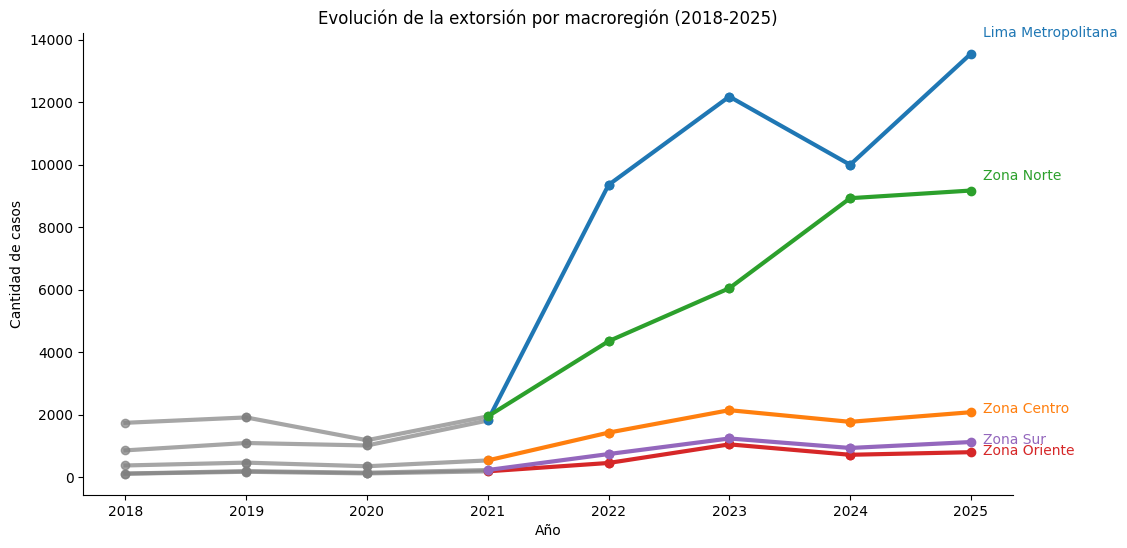

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. Cargar CSV ---
df = pd.read_csv("Denuncias_Policiales_Ene 2018 a Feb 2026.csv", sep=';', encoding="latin-1")

# --- 2. Clasificar zonas ---
def asignar_zona(region):
    region = str(region).strip().upper()
    if region in ["TUMBES", "PIURA", "LAMBAYEQUE", "LA LIBERTAD", "CAJAMARCA"]:
        return "Zona Norte"
    elif region in ["ÁNCASH", "ANCASH", "HUÁNUCO", "HUANUCO", "PASCO",
                    "JUNÍN", "JUNIN", "HUANCAVELICA", "ICA", "LIMA REGION"]:
        return "Zona Centro"
    elif region in ["AREQUIPA", "MOQUEGUA", "TACNA", "CUSCO",
                    "APURÍMAC", "APURIMAC", "AYACUCHO", "PUNO"]:
        return "Zona Sur"
    elif region in ["LORETO", "AMAZONAS", "SAN MARTÍN", "SAN MARTIN",
                    "UCAYALI", "MADRE DE DIOS"]:
        return "Zona Oriente"
    elif "LIMA" in region or "CALLAO" in region:
        return "Lima Metropolitana"
    else:
        return None

df["ZONA"] = df["DPTO_HECHO_NEW"].apply(asignar_zona)
df = df[df["ZONA"].notna()]

# --- 3. Filtrar hasta 2025 ---
df = df[df["ANIO"] <= 2025]

# --- 4. Agrupar ---
df_group = df.groupby(["ANIO", "ZONA", "P_MODALIDADES"])["cantidad"].sum().reset_index()

# --- 5. Filtrar EXTORSIÓN ---
df_ext = df_group[df_group["P_MODALIDADES"].str.contains("EXTORSION|EXTORSIÓN", case=False, na=False)]

# --- 6. Graficar línea continua con degradado gris → color ---
plt.figure(figsize=(12,6))
zonas = df_ext["ZONA"].unique()
colors = sns.color_palette("tab10", len(zonas))

for i, zona in enumerate(zonas):
    data_zona = df_ext[df_ext["ZONA"] == zona].sort_values("ANIO")
    x = data_zona["ANIO"].values
    y = data_zona["cantidad"].values

    # Dibujar línea segmento por segmento con gris hasta 2021, color después
    for j in range(len(x)-1):
        if x[j+1] <= 2021:
            c = 'gray'
            alpha = 0.7
        else:
            c = colors[i]
            alpha = 1.0
        plt.plot(x[j:j+2], y[j:j+2], color=c, linewidth=3, alpha=alpha, marker='o')

    # Etiqueta al costado del último punto
    x_text = x[-1] + 0.1
    y_text = y[-1] * 1.05
    plt.text(x_text, y_text, zona, color=colors[i], fontsize=10, va='center')

# --- Diseño final ---
plt.title("Evolución de la extorsión por macroregión (2018-2025)")
plt.xlabel("Año")
plt.ylabel("Cantidad de casos")
plt.grid(False)
plt.xticks(range(2018,2026))
plt.legend().remove()

# --- Quitar spines derecha y superior ---
ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.show()

In [ ]:
# ================================
# CREAR MACROZONAS Y RECORTARLAS AL PERÚ (CORREGIDO LIMA)
# ================================
minx, miny, maxx, maxy = peru.total_bounds

zonas = [
    ("Zona Norte", box(minx, (maxy+miny)/2, maxx, maxy)),
    ("Zona Centro", box(minx, (maxy+miny)/3, maxx, (maxy+miny)/2)),
    ("Zona Sur", box(minx, miny, maxx, (maxy+miny)/3)),
    ("Zona Oriente", box((minx+maxx)/2, miny, maxx, maxy)),

    # 🔥 LIMA METROPOLITANA (AGRANDADA PARA QUE SE VEA)
    ("Lima Metropolitana", box(minx, miny, minx + (maxx-minx)*0.25, miny + (maxy-miny)*0.25))
]

zonas_geo = []

for nombre, geom in zonas:
    zona_recortada = gpd.overlay(
        gpd.GeoDataFrame(geometry=[geom], crs=peru.crs),
        peru,
        how="intersection"
    )
    zona_recortada["ZONA"] = nombre
    zonas_geo.append(zona_recortada)

zonas_geo = pd.concat(zonas_geo)

# 🔥 Asegurar que nombres coincidan EXACTO
zonas_geo["ZONA"] = zonas_geo["ZONA"].str.strip()
df_group["ZONA"] = df_group["ZONA"].str.strip()

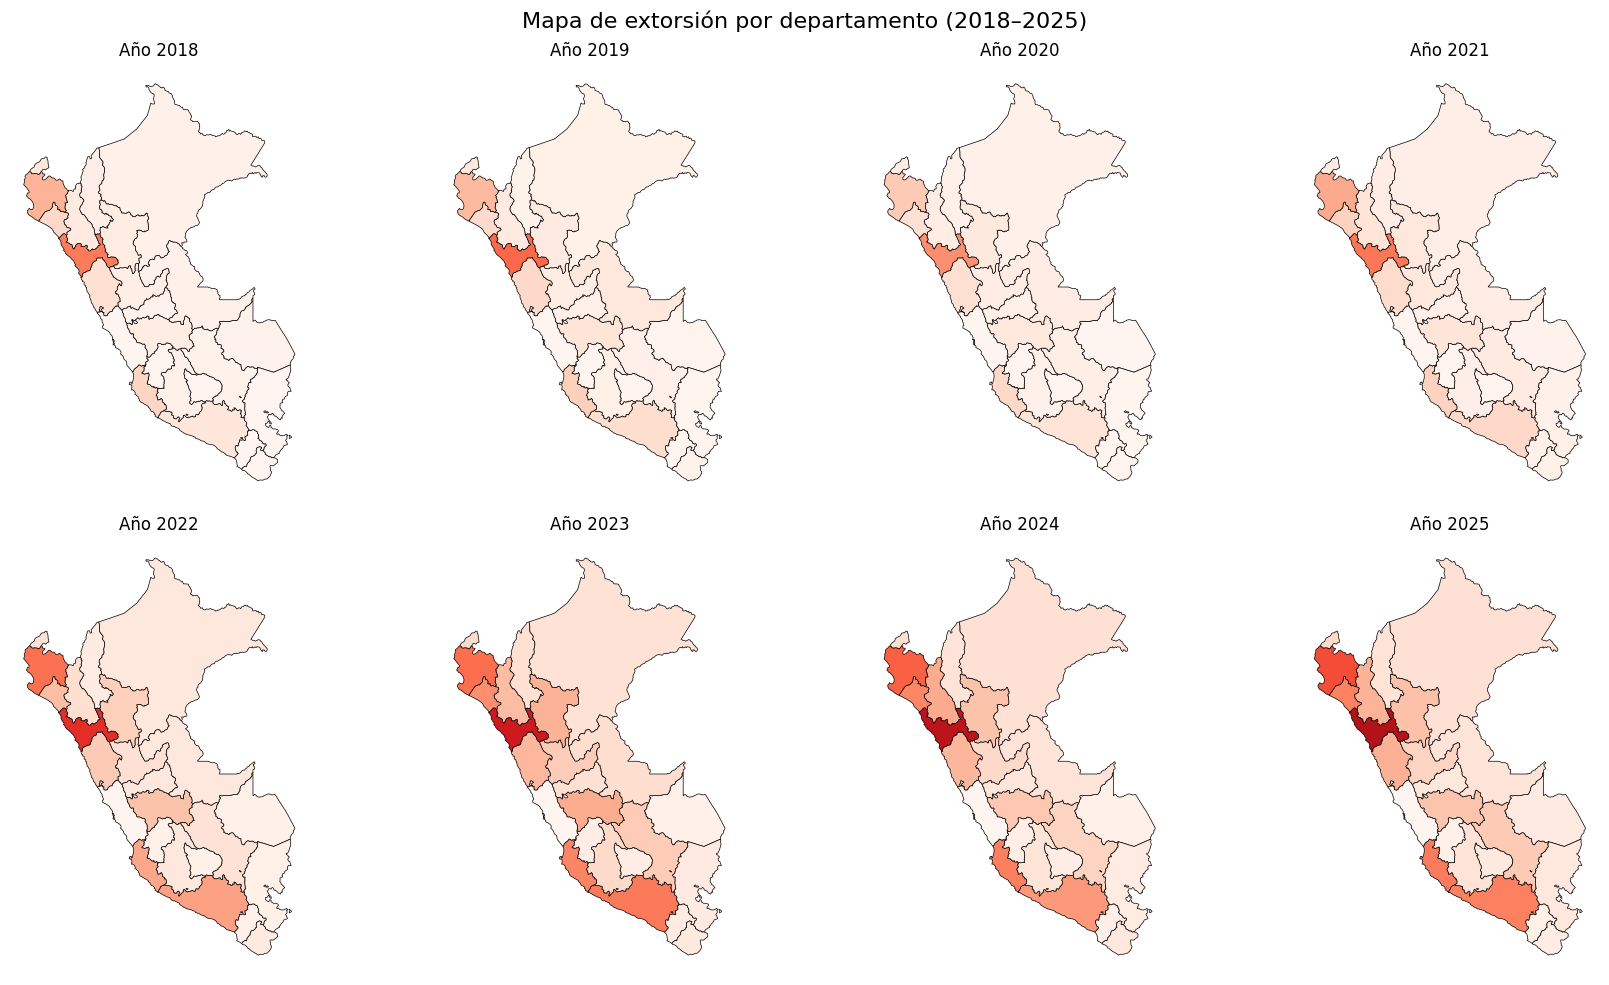

In [ ]:
# ================================
# INSTALAR LIBRERÍAS
# ================================
!pip install geopandas

# ================================
# IMPORTAR LIBRERÍAS
# ================================
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# ================================
# CARGAR DATA
# ================================
df = pd.read_csv("Denuncias_Policiales_Ene 2018 a Feb 2026.csv", sep=';', encoding="latin-1")
df.columns = df.columns.str.upper().str.strip()

# ================================
# FILTRAR EXTORSIÓN
# ================================
df_ext = df[
    df["P_MODALIDADES"].str.contains("EXTORSION|EXTORSIÓN", case=False, na=False)
]

df_ext = df_ext[(df_ext["ANIO"] >= 2018) & (df_ext["ANIO"] <= 2025)]

# ================================
# AGRUPAR POR DEPARTAMENTO
# ================================
df_group = df_ext.groupby(["ANIO", "DPTO_HECHO_NEW"]).size().reset_index(name="cantidad")

# LIMPIAR TEXTO
df_group["DPTO_HECHO_NEW"] = df_group["DPTO_HECHO_NEW"].str.upper().str.strip()

# ================================
# CORREGIR NOMBRES (CLAVE)
# ================================
df_group["DPTO_HECHO_NEW"] = df_group["DPTO_HECHO_NEW"].replace({
    "LIMA REGION": "LIMA",
    "SAN MARTÍN": "SAN MARTIN",
    "ÁNCASH": "ANCASH"
})

# ================================
# CARGAR MAPA REAL POR DEPARTAMENTOS
# ================================
url = "https://raw.githubusercontent.com/juaneladio/peru-geojson/master/peru_departamental_simple.geojson"
mapa_peru = gpd.read_file(url)

# NORMALIZAR NOMBRES
mapa_peru["NOMBDEP"] = mapa_peru["NOMBDEP"].str.upper().str.strip()

# ================================
# CREAR FIGURA
# ================================
years = range(2018, 2026)

fig, axes = plt.subplots(2, 4, figsize=(18,10))
axes = axes.flatten()

# ESCALA GLOBAL (IMPORTANTE)
vmin = df_group["cantidad"].min()
vmax = df_group["cantidad"].max()

for i, year in enumerate(years):
    ax = axes[i]

    data_year = df_group[df_group["ANIO"] == year]

    mapa = mapa_peru.merge(
        data_year,
        left_on="NOMBDEP",
        right_on="DPTO_HECHO_NEW",
        how="left"
    )

    mapa["cantidad"] = mapa["cantidad"].fillna(0)

    mapa.plot(
        column="cantidad",
        cmap="Reds",
        linewidth=0.5,
        edgecolor="black",
        vmin=vmin,
        vmax=vmax,
        ax=ax
    )

    ax.set_title(f"Año {year}")
    ax.axis("off")

plt.suptitle("Mapa de extorsión por departamento (2018–2025)", fontsize=16)
plt.tight_layout()
plt.show()

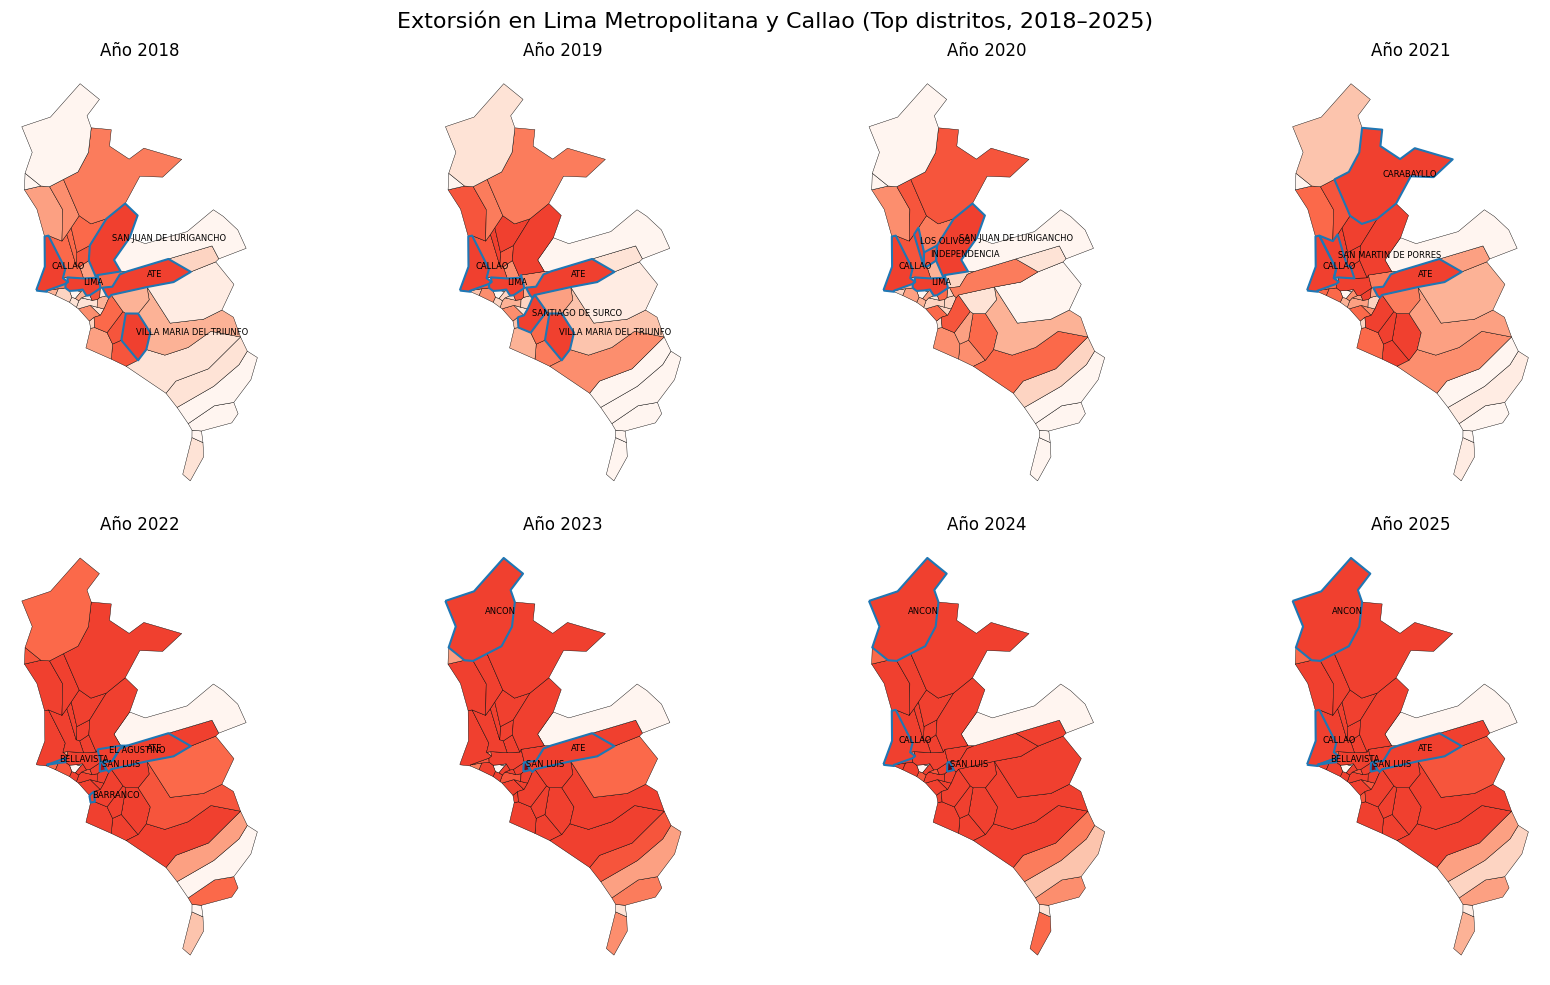

In [ ]:
# ================================
# INSTALAR LIBRERÍAS
# ================================
!pip install geopandas

# ================================
# IMPORTAR LIBRERÍAS
# ================================
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# ================================
# CARGAR DATA
# ================================
df = pd.read_csv("Denuncias_Policiales_Ene 2018 a Feb 2026.csv", sep=';', encoding="latin-1")
df.columns = df.columns.str.upper().str.strip()

# ================================
# FILTRAR LIMA Y CALLAO + EXTORSIÓN
# ================================
df_lima = df[
    df["DPTO_HECHO_NEW"].str.contains("LIMA|CALLAO", case=False, na=False)
]

df_lima = df_lima[
    df_lima["P_MODALIDADES"].str.contains("EXTORSION|EXTORSIÓN", case=False, na=False)
]

df_lima = df_lima[(df_lima["ANIO"] >= 2018) & (df_lima["ANIO"] <= 2025)]

# ================================
# AGRUPAR POR DISTRITO
# ================================
df_group = df_lima.groupby(["ANIO", "DIST_HECHO"]).size().reset_index(name="cantidad")
df_group["DIST_HECHO"] = df_group["DIST_HECHO"].str.upper().str.strip()

# ================================
# CARGAR MAPA (EL QUE SÍ FUNCIONA)
# ================================
url = "https://raw.githubusercontent.com/juaneladio/peru-geojson/master/peru_distrital_simple.geojson"
mapa = gpd.read_file(url)

mapa["NOMBDIST"] = mapa["NOMBDIST"].str.upper().str.strip()
mapa["NOMBDEP"] = mapa["NOMBDEP"].str.upper().str.strip()
mapa["NOMBPROV"] = mapa["NOMBPROV"].str.upper().str.strip()

# ================================
# 🔥 FILTRO CORRECTO
# ================================
mapa_lima = mapa[
    ((mapa["NOMBDEP"] == "LIMA") & (mapa["NOMBPROV"] == "LIMA")) |
    (mapa["NOMBDEP"] == "CALLAO")
]

# ================================
# FIGURA
# ================================
years = range(2018, 2026)

fig, axes = plt.subplots(2, 4, figsize=(18,10))
axes = axes.flatten()

vmin = df_group["cantidad"].min()
vmax = df_group["cantidad"].max()

for i, year in enumerate(years):
    ax = axes[i]

    data_year = df_group[df_group["ANIO"] == year]

    mapa_year = mapa_lima.merge(
        data_year,
        left_on="NOMBDIST",
        right_on="DIST_HECHO",
        how="left"
    )

    mapa_year["cantidad"] = mapa_year["cantidad"].fillna(0)

    # mapa base
    mapa_year.plot(
        column="cantidad",
        cmap="Reds",
        linewidth=0.3,
        edgecolor="black",
        vmin=vmin,
        vmax=vmax,
        ax=ax
    )

    # ================================
    # 🔥 TOP 5 DISTRITOS
    # ================================
    top5 = data_year.sort_values("cantidad", ascending=False).head(5)
    mapa_top = mapa_year[mapa_year["NOMBDIST"].isin(top5["DIST_HECHO"])]

    mapa_top.boundary.plot(ax=ax, linewidth=1.5)

    for _, row in mapa_top.iterrows():
        if row.geometry is not None:
            x, y = row.geometry.centroid.coords[0]
            ax.text(x, y, row["NOMBDIST"], fontsize=6)

    ax.set_title(f"Año {year}")
    ax.axis("off")

plt.suptitle("Extorsión en Lima Metropolitana y Callao (Top distritos, 2018–2025)", fontsize=16)
plt.tight_layout()
plt.show()